In [105]:
import numpy as np
import pandas as pd

In [106]:
df = pd.read_csv("/home/junix/sms-spam-classifier/spam.csv", encoding="latin-1")
print(df)

        v1                                                 v2 Unnamed: 2  \
0      ham  Go until jurong point, crazy.. Available only ...        NaN   
1      ham                      Ok lar... Joking wif u oni...        NaN   
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3      ham  U dun say so early hor... U c already then say...        NaN   
4      ham  Nah I don't think he goes to usf, he lives aro...        NaN   
...    ...                                                ...        ...   
5567  spam  This is the 2nd time we have tried 2 contact u...        NaN   
5568   ham              Will Ì_ b going to esplanade fr home?        NaN   
5569   ham  Pity, * was in mood for that. So...any other s...        NaN   
5570   ham  The guy did some bitching but I acted like i'd...        NaN   
5571   ham                         Rofl. Its true to its name        NaN   

     Unnamed: 3 Unnamed: 4  
0           NaN        NaN  
1           NaN        NaN  


In [107]:
df.shape

(5572, 5)

In [108]:
# 1. cleeaning the data
# 2. EDA
# 3. Text Preprocessing
# 4. Model Building
# 5. Model Evaluation
# 6. Improvement
# 7. Website
# 8. Deploy

In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [110]:
df.drop(columns=["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"], inplace=True)

In [111]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [112]:
df.rename(columns={"v1": "target", "v2": "text"}, inplace=True)
df.sample(8)

,target,text
4941,ham,"I'm eatin now lor, but goin back to work soon...."
49,ham,U don't know how stubborn I am. I didn't even ...
3315,ham,I know girls always safe and selfish know i go...
1932,ham,Jus finished avatar nigro
326,ham,Hi da:)how is the todays class?
2636,ham,Thank god they are in bed!
3578,ham,Multiply the numbers independently and count d...
3155,ham,Long time. You remember me today.


In [113]:
# df["target"] = df["target"].map({"ham": "0", "spam": "1"})
# df.sample(10)

In [114]:
# df["target"] = (df["target"] == "ham").astype(int)
# df.head()

In [115]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df["target"] = encoder.fit_transform(df["target"])
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [116]:
#checking for missing and duplicate values
print(df.isnull().sum())


target    0
text      0
dtype: int64


In [117]:
print(df.duplicated().sum())

403


In [118]:
df = df.drop_duplicates(keep="first")
print(df.duplicated().sum())

0


In [119]:
df.shape

(5169, 2)

In [120]:
df.value_counts()

target  text                                                                                                                                                                          
0        &lt;#&gt;  in mca. But not conform.                                                                                                                                              1
         &lt;#&gt;  mins but i had to stop somewhere first.                                                                                                                               1
         &lt;DECIMAL&gt; m but its not a common car here so its better to buy from china or asia. Or if i find it less expensive. I.ll holla                                              1
         and  picking them up from various points                                                                                                                                         1
         came to look at the flat, seems ok, in his 50s? * Is awa

In [121]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

In [122]:
import matplotlib.pyplot as plt
import seaborn as sns

([<matplotlib.patches.Wedge at 0x7f370b088f50>,
 [Text(-1.014499732282844, 0.4251944181172162, 'ham'),
  Text(1.0144998708287172, -0.42519408755122207, 'spam')],
 [Text(-0.5533634903360967, 0.2319242280639361, '87.37'),
  Text(0.553363565906573, -0.231924047755212, '12.63')])

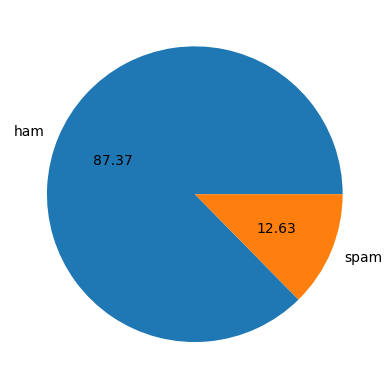

In [123]:
plt.pie(df['target'].value_counts(), labels=['ham', 'spam'], autopct="%0.2f")
#autopct is used to show the percentage of each class in the pie chart and %0.2f is used to format the percentage to 2 decimal places

In [124]:
#notice rhat the data is imbalanced!

In [125]:
pip install nltk

Note: you may need to restart the kernel to use updated packages.


In [126]:
import nltk
nltk.download("punkt")

[nltk_data] Downloading package punkt to /home/junix/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [127]:
#adding a new column for the number of characters in the text message
df["num_characters"] = df["text"].apply(len)
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [128]:
df["num_words"] = df["text"].apply(lambda x: len(nltk.word_tokenize(x)))
df["num_sentences"] = df["text"].apply(lambda x: len(nltk.sent_tokenize(x)))
df.head()   

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [129]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5169 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   target          5169 non-null   int64 
 1   text            5169 non-null   object
 2   num_characters  5169 non-null   int64 
 3   num_words       5169 non-null   int64 
 4   num_sentences   5169 non-null   int64 
dtypes: int64(4), object(1)
memory usage: 242.3+ KB


In [130]:
df[['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [131]:
df[df['target'] == '1'][['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,0.0,0.0,0.0
mean,NaN,NaN,NaN
std,NaN,NaN,NaN
min,NaN,NaN,NaN
25%,NaN,NaN,NaN
50%,NaN,NaN,NaN
75%,NaN,NaN,NaN
max,NaN,NaN,NaN


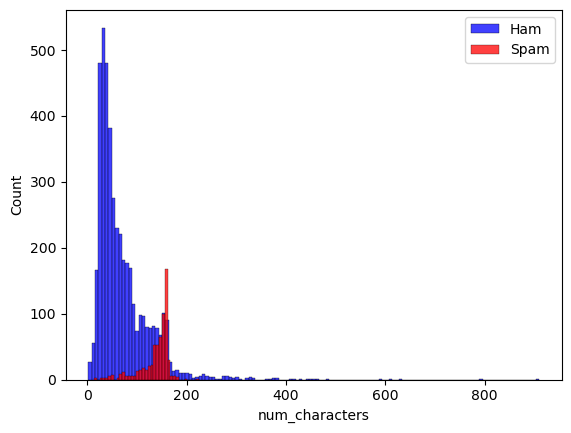

In [132]:
sns.histplot(df[df['target'] == 0]['num_characters'], color = 'blue', label='Ham')
sns.histplot(df[df['target'] == 1]['num_characters'], color = 'red', label='Spam')
plt.legend()

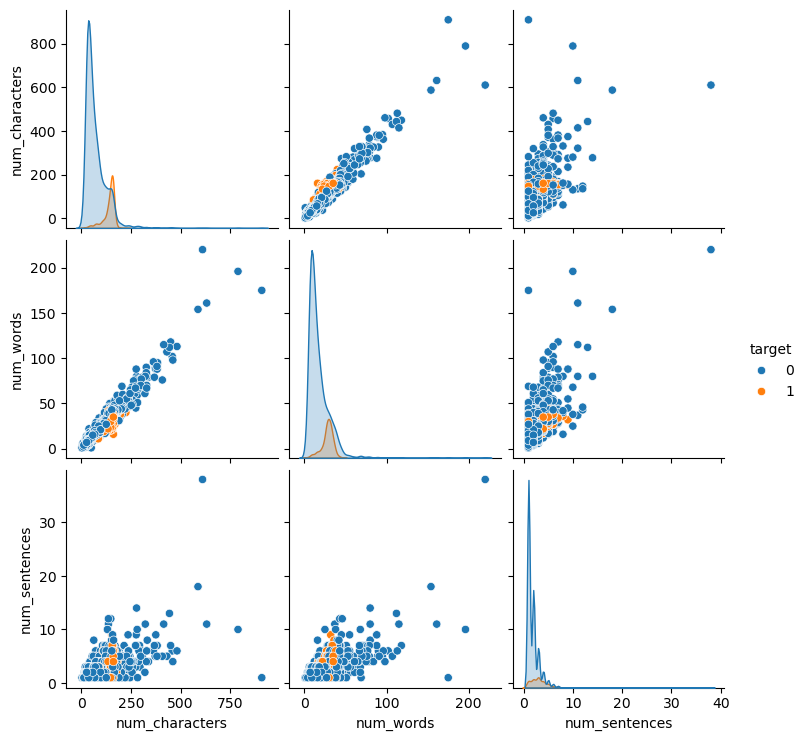

In [133]:
sns.pairplot(df, hue='target')

<Axes: >

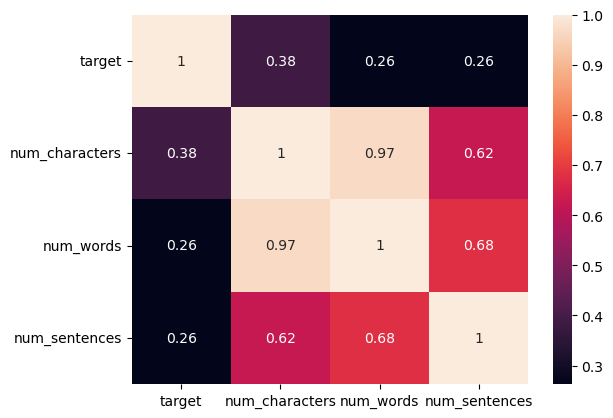

In [134]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [135]:
#text preprocessing

In [136]:
def text_preprocessing(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    y = []
    
    for i in text:
        if i.isalnum():
            y.append(i)
            
    text = y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words("english") and i not in string.punctuation:
            y.append(i)
    
    text = y[:]
    y.clear()

    for i in text:
        y.append(lemmatizer.lemmatize(i))

    return y

In [137]:
from nltk.corpus import stopwords
import string


In [138]:
text_preprocessing("????????????????????If you're visiting this page, you're likely here because you're")

['visiting', 'page', 'likely']

In [139]:
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

In [140]:
df['transformed_text'] = df['text'].apply(text_preprocessing)

In [141]:
df.sample(7)

,target,text,num_characters,num_words,num_sentences,transformed_text
2256,0,"Just checked out, heading out to drop off my s...",54,12,1,"[checked, heading, drop, stuff]"
471,0,"How long has it been since you screamed, princ...",50,11,1,"[long, since, screamed, princess]"
4681,0,"Haha yeah, 2 oz is kind of a shitload",37,10,1,"[haha, yeah, 2, oz, kind, shitload]"
3132,0,So no messages. Had food?,25,7,2,"[message, food]"
2375,0,Thanx 4 2day! U r a goodmate I THINK UR RITE S...,95,25,4,"[thanx, 4, 2day, u, r, goodmate, think, ur, ri..."
3777,0,Once a fishrman woke early in d mrng. It was v...,302,77,6,"[fishrman, woke, early, mrng, dark, waited, am..."
5362,0,I'm in inside office..still filling forms.don ...,70,15,1,"[inside, office, still, filling, know, leave]"


In [144]:
from wordcloud import WordCloud
wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')

In [143]:
pip install wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 550.7/550.7 kB 3.9 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [147]:
spam_text = df.loc[df['target'] == 1, 'transformed_text'].fillna('').astype(str).str.cat(sep=' ')
spam_wc = wc.generate(spam_text)

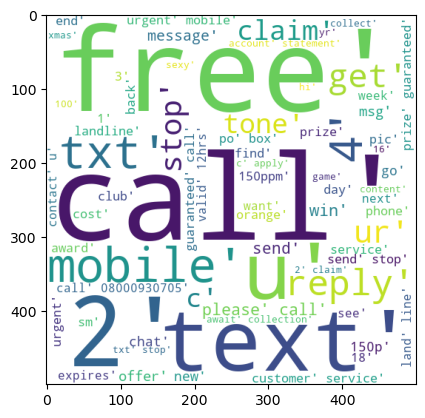

In [148]:
plt.imshow(spam_wc)

In [149]:
ham_text = df.loc[df['target'] == 0, 'transformed_text'].fillna('').astype(str).str.cat(sep=' ')
ham_wc = wc.generate(ham_text)

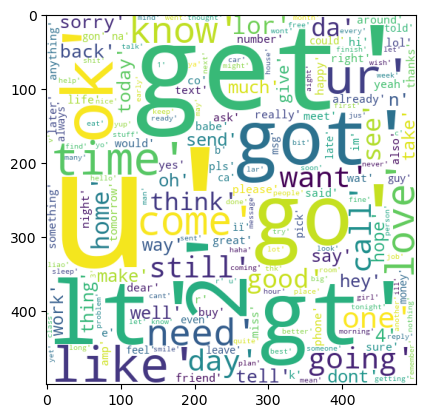

In [150]:
plt.imshow(ham_wc)

In [154]:
spam_corpus = []
for msg in df[df['target'] == 1]['transformed_text'].tolist():
    for word in msg:
        spam_corpus.append(word)

In [155]:
len(spam_corpus)

9939

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29],
 [Text(0, 0, 'call'),
  Text(1, 0, 'free'),
  Text(2, 0, '2'),
  Text(3, 0, 'txt'),
  Text(4, 0, 'u'),
  Text(5, 0, 'text'),
  Text(6, 0, 'ur'),
  Text(7, 0, 'mobile'),
  Text(8, 0, 'stop'),
  Text(9, 0, 'claim'),
  Text(10, 0, 'reply'),
  Text(11, 0, '4'),
  Text(12, 0, 'prize'),
  Text(13, 0, 'c'),
  Text(14, 0, 'get'),
  Text(15, 0, 'new'),
  Text(16, 0, 'service'),
  Text(17, 0, 'tone'),
  Text(18, 0, 'send'),
  Text(19, 0, 'urgent'),
  Text(20, 0, 'nokia'),
  Text(21, 0, 'phone'),
  Text(22, 0, 'cash'),
  Text(23, 0, 'contact'),
  Text(24, 0, 'week'),
  Text(25, 0, 'please'),
  Text(26, 0, 'win'),
  Text(27, 0, 'min'),
  Text(28, 0, 'customer'),
  Text(29, 0, 'guaranteed')])

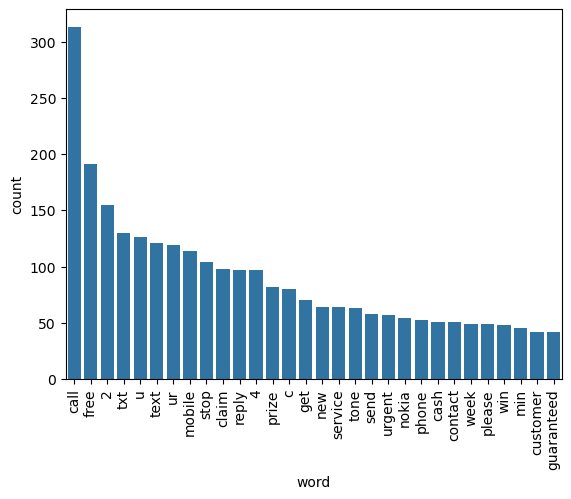

In [158]:
from collections import Counter
counter_df = pd.DataFrame(Counter(spam_corpus).most_common(30), columns=['word', 'count'])
sns.barplot(data=counter_df, x='word', y='count')
plt.xticks(rotation='vertical')

In [159]:
ham_corpus = []
for msg in df[df['target'] == 0]['transformed_text'].tolist():
    for word in msg:
        ham_corpus.append(word)

In [160]:
len(ham_corpus)

35404

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29],
 [Text(0, 0, 'u'),
  Text(1, 0, 'get'),
  Text(2, 0, 'gt'),
  Text(3, 0, 'lt'),
  Text(4, 0, '2'),
  Text(5, 0, 'go'),
  Text(6, 0, 'got'),
  Text(7, 0, 'know'),
  Text(8, 0, 'come'),
  Text(9, 0, 'like'),
  Text(10, 0, 'ok'),
  Text(11, 0, 'time'),
  Text(12, 0, 'good'),
  Text(13, 0, 'ur'),
  Text(14, 0, 'call'),
  Text(15, 0, 'day'),
  Text(16, 0, 'want'),
  Text(17, 0, 'love'),
  Text(18, 0, 'need'),
  Text(19, 0, 'one'),
  Text(20, 0, 'going'),
  Text(21, 0, 'lor'),
  Text(22, 0, '4'),
  Text(23, 0, 'home'),
  Text(24, 0, 'still'),
  Text(25, 0, 'da'),
  Text(26, 0, 'see'),
  Text(27, 0, 'think'),
  Text(28, 0, 'r'),
  Text(29, 0, 'back')])

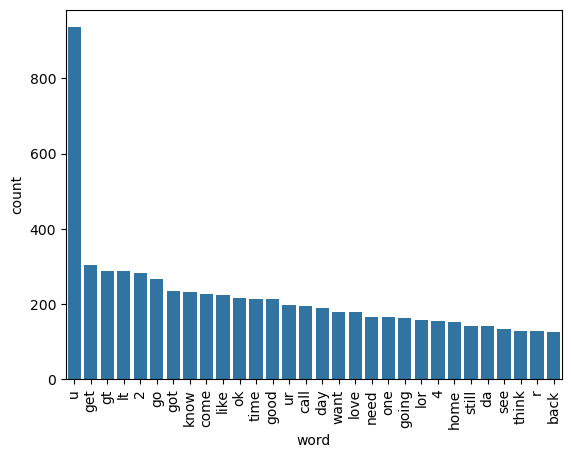

In [161]:
from collections import Counter
counter_df = pd.DataFrame(Counter(ham_corpus).most_common(30), columns=['word', 'count'])
sns.barplot(data=counter_df, x='word', y='count')
plt.xticks(rotation='vertical')